IMPORTING THE NECCESARY LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame= True)

df = housing.frame
X = housing.data
y = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# The dimensions of the dataset
df.shape

(20640, 9)

In [4]:
# The names of all variables
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [5]:
# The data type of each variable
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [6]:
#  missing values 
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [7]:
#  duplicate values
df.duplicated().any()

np.False_

In [8]:
# Descriptive statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


CHECKING FOR OUTLIERS USING A FOR LOOP

In [9]:
Q1 = df["MedInc"].quantile(0.25)
Q3 = df["MedInc"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["MedInc"] < lower_bound) | (df["MedInc"] > upper_bound)]
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.52600
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.58500
131,11.6017,18.0,8.335052,1.082474,533.0,2.747423,37.84,-122.19,3.92600
134,8.2049,28.0,6.978947,0.968421,463.0,2.436842,37.83,-122.19,3.35200
135,8.4010,26.0,7.530806,1.056872,542.0,2.568720,37.83,-122.20,3.51200
...,...,...,...,...,...,...,...,...,...
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001
20427,8.6499,4.0,7.236059,1.032528,5495.0,2.553439,34.19,-118.80,5.00001
20428,8.7288,6.0,8.715842,1.102970,3385.0,3.351485,34.23,-118.83,4.25800
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69,5.00001


In [10]:
Q1 = df["AveRooms"].quantile(0.25)
Q3 = df["AveRooms"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["AveRooms"] < lower_bound) | (df["AveRooms"] > upper_bound)]
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
73,0.4999,46.0,1.714286,0.571429,18.0,2.571429,37.81,-122.29,0.67500
155,8.8793,52.0,8.972868,1.131783,861.0,3.337209,37.81,-122.23,4.10300
511,13.4990,42.0,8.928358,1.000000,1018.0,3.038806,37.82,-122.22,5.00001
512,12.2138,52.0,9.210227,1.039773,1001.0,2.843750,37.82,-122.23,5.00001
514,12.3804,52.0,9.122715,1.033943,1192.0,3.112272,37.82,-122.23,5.00001
...,...,...,...,...,...,...,...,...,...
20408,7.7889,26.0,8.730038,1.045627,842.0,3.201521,34.19,-118.88,3.09900
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001
20428,8.7288,6.0,8.715842,1.102970,3385.0,3.351485,34.23,-118.83,4.25800
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69,5.00001


In [11]:
def outliers(df):
    num_cols = df.select_dtypes(include= 'number').columns
    
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR 
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        print(f'{col}: {outlier_count} outliers')
        
        
outliers(df)

MedInc: 681 outliers
HouseAge: 0 outliers
AveRooms: 511 outliers
AveBedrms: 1424 outliers
Population: 1196 outliers
AveOccup: 711 outliers
Latitude: 0 outliers
Longitude: 0 outliers
MedHouseVal: 1071 outliers


EXPLORATORY DATA ANALYSIS

Text(0, 0.5, 'Frequency')

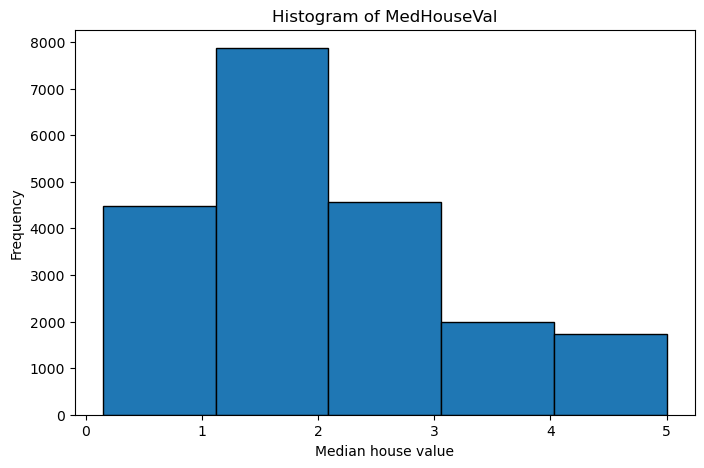

In [12]:
# A histogram of MedHouseVal

plt.figure(figsize=(8,5))
plt.hist(df["MedHouseVal"], bins=5, edgecolor= "black")

plt.title("Histogram of MedHouseVal")
plt.xlabel("Median house value")
plt.ylabel("Frequency")

In [13]:
#  correlation matrix 
correlation_matrix = df.corr()
correlation_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


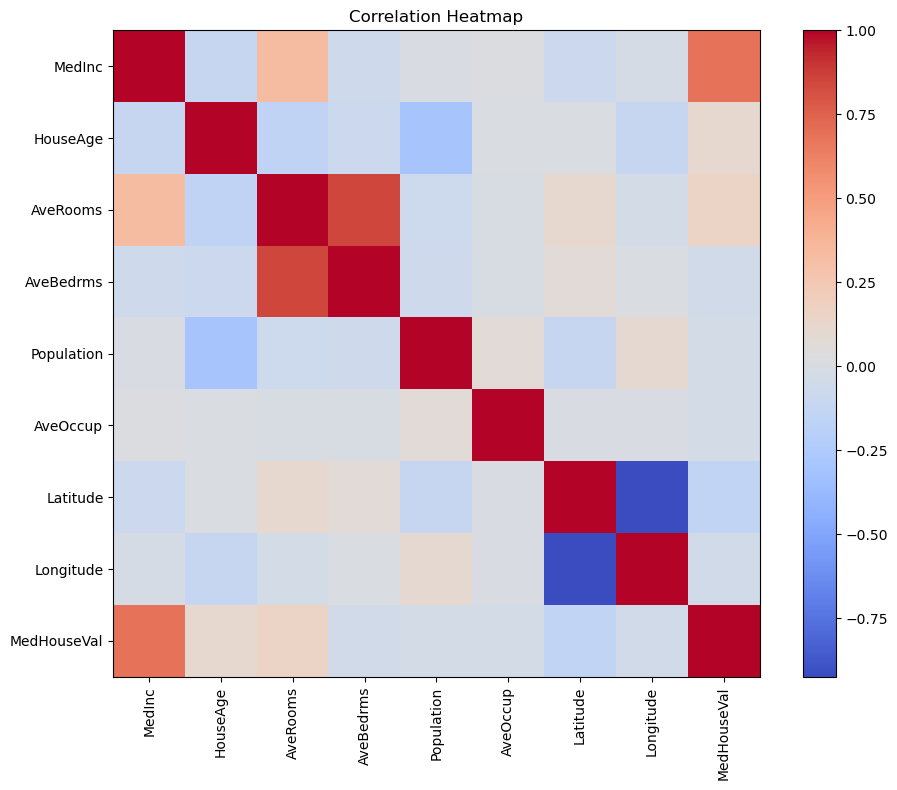

In [14]:
# Correlation Heat Map

plt.figure(figsize=(10,8))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

VISUALIZING USING THE SEABORN

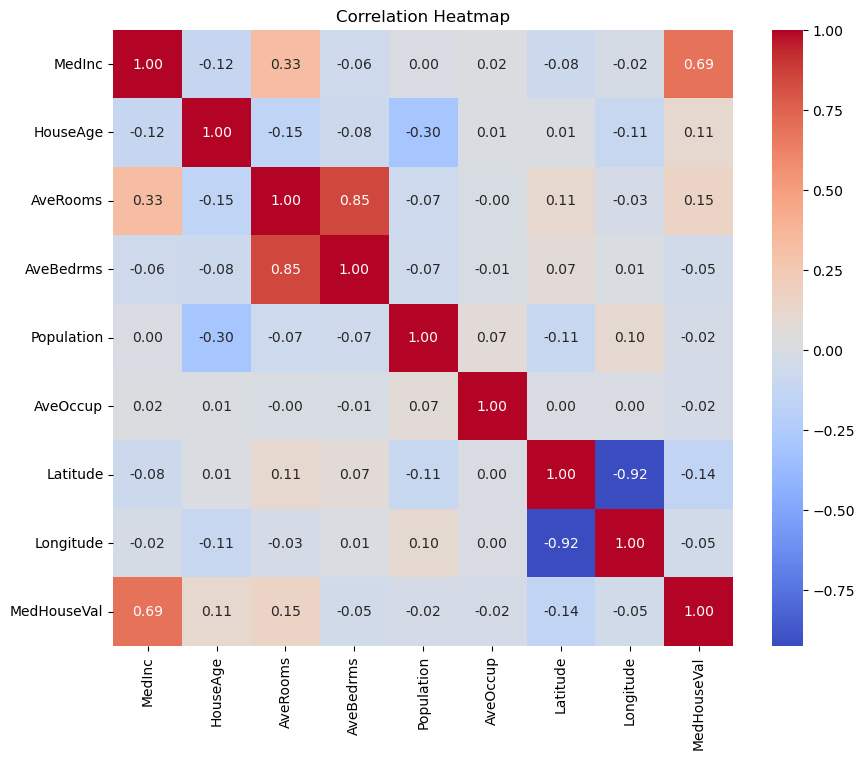

In [15]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Text(0, 0.5, 'Median House Value')

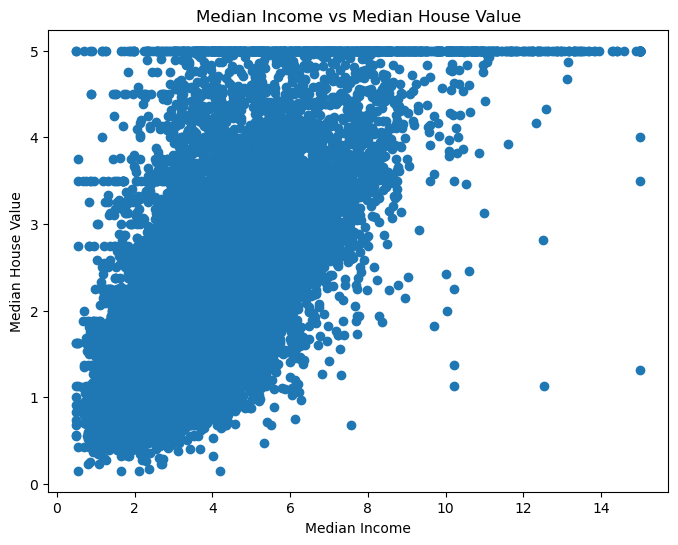

In [16]:
# Scatter plot of MedInc and MedHouseVal
plt.figure(figsize=(8,6))

plt.scatter(df["MedInc"], df["MedHouseVal"])

plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

Text(0, 0.5, 'Median House Value')

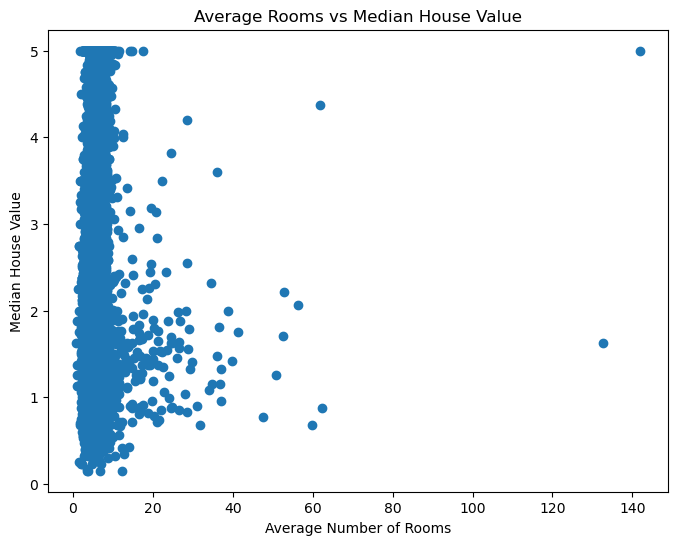

In [17]:
# Scatter plot of AveRooms and MedHouseVal

plt.figure(figsize=(8, 6))
plt.scatter(df["AveRooms"], df["MedHouseVal"])

plt.title("Average Rooms vs Median House Value")
plt.xlabel("Average Number of Rooms")
plt.ylabel("Median House Value")

Feature Encoding and scaling 

In [18]:
# Standardization Scaling because we are using a linear regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = df[
    ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude']
   ] = scaler.fit_transform(df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude']]
                            )

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,4.526
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,3.585
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,3.521
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,3.413
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,3.422


In [19]:
# TRAIN-TEST SPLIT

# Splitting the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle = True, random_state=42)

Model Fitting 

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
# Computing the slopes and bias
slope = model.coef_
intercept = model.intercept_

print("Slope:", slope)
print("Bias:", intercept)

Slope: [ 0.85238169  0.12238224 -0.30511591  0.37113188 -0.00229841 -0.03662363
 -0.89663505 -0.86892682]
Bias: 2.067862309508392


Model Evaluation

CHECKING THE PERFORMANCE OF THE MODEL ON THE TEST SET

In [22]:
y_pred_test = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE: 0.5559
MAE: 0.5332
RMSE: 0.7456
R²   : 0.5758


CHECKING THE PERFORMANCE OF THE MODEL ON THE TRAIN SET

In [23]:
y_pred_train = model.predict(X_train)

mse = mean_squared_error(y_train, y_pred_train)
mae = mean_absolute_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred_train)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE: 0.5179
MAE: 0.5286
RMSE: 0.7197
R²   : 0.6126


In [24]:
data = {"Train": {"MSE": 0.5179, "MAE": 0.5286, "RMSE": 0.7197, "R_squared": 0.6126}, 
       "Test": {"MSE": 0.5559, "MAE": 0.5332, "RMSE": 0.7456, "R_squared": 0.5758} }
computed = pd.DataFrame(data)
computed

,Train,Test
MSE,0.5179,0.5559
MAE,0.5286,0.5332
RMSE,0.7197,0.7456
R_squared,0.6126,0.5758


Based on the training and testing result, the model appears to be generalizing well.

This is because both results are not so far from each other

Question 3: Five-Fold Cross-Validation 

In [25]:
from sklearn.model_selection import KFold, cross_validate
cv =  KFold(n_splits=5, shuffle=True, random_state=42 
    )

WHY SHUFFLING AND FIXED RANDOM STATE ARE USEFUL


Shuffling is used to randomly mix the dataset before splitting so that both the training and test sets contain a representative sample of the data.

A fixed random state ensures that the same training and test sets are generated every time the code is run, which helps with consistency.

Cross-Validation Implementation 

In [26]:
results = cross_validate(model, X_train, y_train, cv=cv, scoring={
    "mse": "neg_mean_squared_error"
})

# Converting the negative values to positive
mse_scores = -results["test_mse"]

print("MSE for each fold:", mse_scores)
print("Average MSE:", mse_scores.mean())

MSE for each fold: [0.53860597 0.5258672  0.48618359 0.53783427 0.50814408]
Average MSE: 0.5193270208432319


COMPARISON

In [27]:
data = {"Single Train": {"MSE": 0.5179}, 
       "Average Train": {"MSE": 0.5193} }
computed = pd.DataFrame(data)
computed

,Single Train,Average Train
MSE,0.5179,0.5193


Question 4: Ridge Regression Using GridSearchCV 

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

In [29]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

In [30]:
ridge_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_ridge = GridSearchCV(
    estimator=ridge,
    param_grid= ridge_grid, cv=cv,
    scoring= "neg_mean_squared_error"
)

grid_ridge.fit(X_train, y_train)

print("Best alpha:", grid_ridge.best_params_)
print("Best CV Score:", grid_ridge.best_score_)

best_ridge = grid_ridge.best_estimator_

Best alpha: {'model__alpha': 1}
Best CV Score: -0.5193263909536286


MODEL EVALUATION

In [31]:
# Making Prediction for the test set
ridge_pred = best_ridge.predict(X_test)

mse = mean_squared_error(y_test, ridge_pred)
mae = mean_absolute_error(y_test, ridge_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, ridge_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE: 0.5559
MAE: 0.5332
RMSE: 0.7456
R²   : 0.5758


In [32]:
# Making Prediction for the train set
ridge_pred = best_ridge.predict(X_train)

mse = mean_squared_error(y_train, ridge_pred)
mae = mean_absolute_error(y_train, ridge_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, ridge_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE: 0.5179
MAE: 0.5286
RMSE: 0.7197
R²   : 0.6126


INTERPRETATION

Ridge Regression applies a penalty that shrinks the regression coefficients toward zero by penalizing large coefficient values. 

No, Ridge Regression does not normally reduce coefficients exactly to zero.

Question 5: Lasso Regression Using GridSearchCV

In [33]:
model2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())
])

In [34]:
lasso_grid = {
    "model__alpha": [ 
0.0001, 
0.001, 
0.01, 
0.05, 
0.1, 
0.5, 
1, 
5, 
10 ]
}

# Dividing the dataset into 5 fold CV
grid_lasso = GridSearchCV(
    estimator= model2,
    param_grid= lasso_grid, cv=5,
    scoring= 'neg_mean_squared_error'
)

grid_lasso.fit(X_train, y_train)

print("Best Alpha:", grid_lasso.best_params_)
print("Best CV Score:", grid_lasso.best_score_)

best_lasso = grid_lasso.best_estimator_

Best Alpha: {'model__alpha': 0.0001}
Best CV Score: -0.5192596629346556


In [35]:
# Making Prediction for the test set
lasso_pred = best_lasso.predict(X_test)

mse = mean_squared_error(y_test, lasso_pred)
mae = mean_absolute_error(y_test, lasso_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lasso_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE: 0.5557
MAE: 0.5332
RMSE: 0.7455
R²   : 0.5759


In [36]:
# Making Prediction for the train set
lasso_pred = best_lasso.predict(X_train)

mse = mean_squared_error(y_train, lasso_pred)
mae = mean_absolute_error(y_train, lasso_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, lasso_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE: 0.5179
MAE: 0.5286
RMSE: 0.7197
R²   : 0.6126


Feature Selection 

In [37]:
# Number of coefficients reduced exactly to zero
coefficients = best_lasso.named_steps["model"].coef_
zero_coefficients = (coefficients == 0).sum()

print("Number of coefficients reduced to zero:", zero_coefficients)

Number of coefficients reduced to zero: 0


There was no variable removed by Lasso

Lasso Regression can be used as a feature selection method because it applies an L1 penalty that shrinks some regression coefficients exactly to zero.

Question 6: Elastic Net Regression Using GridSearchCV 

In [38]:
model3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter= 10000))
])

In [39]:
elastic_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10 ],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_elastic = GridSearchCV(
    estimator= model3,
    param_grid= elastic_grid, cv=5,
    scoring= "neg_mean_squared_error"
)

grid_elastic.fit(X_train, y_train)

print("Best Parameters:", grid_elastic.best_params_)
print("Best CV MSE:", grid_elastic.best_score_)

best_elastic = grid_elastic.best_estimator_

Best Parameters: {'model__alpha': 0.0001, 'model__l1_ratio': 0.9}
Best CV MSE: -0.5192602553975534


In [40]:
# Making Prediction for the test set
elastic_pred = best_elastic.predict(X_test)

mse = mean_squared_error(y_test, elastic_pred)
mae = mean_absolute_error(y_test, elastic_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, elastic_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE: 0.5558
MAE: 0.5332
RMSE: 0.7455
R²   : 0.5759


In [41]:
# Making Prediction for the train set
elastic_pred = best_elastic.predict(X_train)

mse = mean_squared_error(y_train, elastic_pred)
mae = mean_absolute_error(y_train, elastic_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, elastic_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE: 0.5179
MAE: 0.5286
RMSE: 0.7197
R²   : 0.6126


Interpretation 

Elastic Net combines the characteristics of Ridge and Lasso Regression by applying both L2 and L1 regularization penalties. The L2 penalty shrinks the regression coefficients toward zero to reduce overfitting, while the L1 penalty can reduce some coefficients exactly to zero.

In [42]:
# Number of coefficients reduced exactly to zero
coefficients = best_elastic.named_steps["model"].coef_
zero_coefficients = (coefficients == 0).sum()

print("Number of coefficients reduced to zero:", zero_coefficients)


Number of coefficients reduced to zero: 0


Question 7: Model Performance Comparison 

In [43]:
table = {"Model": ["Linear Regression", "Ridge", "Lasso", "Elastic Net"], 
       "Optimal Alpha": ["N/A", 1, 0.0001, 0.0001],
       "Optimal L1 Ratio": ["N/A", "N/A", "N/A", 0.9], 
       "Test MSE": [0.5559, 0.5559, 0.5557, 0.5558],
       "Test RMSE": [0.7456, 0.7456, 0.7455, 0.7455], 
       "Test MAE": [0.5332, 0.5332, 0.5332, 0.5332],
       "R²": [0.5758, 0.5758, 0.5759, 0.5759]
       }
created_table = pd.DataFrame(table)
created_table

,Model,Optimal Alpha,Optimal L1 Ratio,Test MSE,Test RMSE,Test MAE,R²
0,Linear Regression,N/A,N/A,0.5559,0.7456,0.5332,0.5758
1,Ridge,1,N/A,0.5559,0.7456,0.5332,0.5758
2,Lasso,0.0001,N/A,0.5557,0.7455,0.5332,0.5759
3,Elastic Net,0.0001,0.9,0.5558,0.7455,0.5332,0.5759


Which model has the lowest test MSE?  

Lasso



Which model has the lowest test RMSE?  

Lasso and Elastic Net



Which model has the lowest test MAE? 

Lasso and Elastic Net



Which model has the highest test 𝑅2? 

Lasso and Elastic Net



Did regularisation improve predictive performance?  

Yes, regularization improved the predictive performance of Lasso and Elastic Net. However, Ridge remained the same as the Linear Regression.



Are the differences between the models practically important?  

No, the difference are not practically important. This is because the differences are extremely small.



Which model would you recommend for prediction?

Based on the result, I will recommend the Linear regression for prediction. 



Give a reason for your recommendation.

This is because, since all the models perform almost the same so it is preferable to choose the simplest model for prediction.

Question 8: Coefficient Shrinkage Comparison 

In [44]:
model4 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [45]:
model4.fit(X_train, y_train)


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [46]:
# FITTING THE MODEL 

y_pred = model4.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE: 0.5559
MAE: 0.5332
RMSE: 0.7456
R²   : 0.5758


In [47]:
# EXTRACTING THE REGULARIZED MODEL COEFFICIENTS

best_lasso.named_steps["model"].coef_

array([ 0.85386139,  0.12262672, -0.29310099,  0.33794196, -0.00218297,
       -0.04073526, -0.89581225, -0.86866153])

In [48]:
best_ridge.named_steps["model"].coef_

array([ 0.85432679,  0.12262397, -0.29421036,  0.33900794, -0.00228221,
       -0.04083302, -0.89616759, -0.86907074])

In [49]:
best_elastic.named_steps["model"].coef_

array([ 0.85390439,  0.12263151, -0.29319917,  0.33803239, -0.00219124,
       -0.04074529, -0.89579808, -0.86865214])

In [50]:
model4.named_steps["model"].coef_

array([ 0.85438303,  0.12254624, -0.29441013,  0.33925949, -0.00230772,
       -0.0408291 , -0.89692888, -0.86984178])

In [51]:
data1 = {
    "Feature": ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"],
    "Linear Regression": [0.85438303,  0.12254624, -0.29441013,  0.33925949, -0.00230772,
       -0.0408291 , -0.89692888, -0.86984178],
    "Lasso": [0.85386139,  0.12262672, -0.29310099,  0.33794196, -0.00218297,
       -0.04073526, -0.89581225, -0.86866153],
    "Ridge": [0.85432679,  0.12262397, -0.29421036,  0.33900794, -0.00228221,
       -0.04083302, -0.89616759, -0.86907074],
    "Elastic Net": [0.85390439,  0.12263151, -0.29319917,  0.33803239, -0.00219124,
       -0.04074529, -0.89579808, -0.86865214]
}

coefficient = pd.DataFrame(data1)
coefficient

,Feature,Linear Regression,Lasso,Ridge,Elastic Net
0,MedInc,0.854383,0.853861,0.854327,0.853904
1,HouseAge,0.122546,0.122627,0.122624,0.122632
2,AveRooms,-0.294410,-0.293101,-0.294210,-0.293199
3,AveBedrms,0.339259,0.337942,0.339008,0.338032
4,Population,-0.002308,-0.002183,-0.002282,-0.002191
5,AveOccup,-0.040829,-0.040735,-0.040833,-0.040745
6,Latitude,-0.896929,-0.895812,-0.896168,-0.895798
7,Longitude,-0.869842,-0.868662,-0.869071,-0.868652


Which model produces the largest coefficient magnitudes?  

Linear Regression.



Does Ridge shrink most coefficients towards zero?

Yes, Ridge shrinks most of the coefficients towards zero



Does Ridge set any coefficients exactly to zero?  

No, it does not, but it shrinks them towards zero.



Which coefficients are set to zero by Lasso?  

None



Which coefficients are set to zero by Elastic Net? 

None



Which model produces the sparsest solution?  

None of the models produced a sparse solution because all eight features have non-zero coefficients.



Which model is most appropriate for automatic feature selection? 

Lasso, because it shrinks irrelevant features to zero.



Which model is generally more suitable when predictors are strongly correlated? 

Ridge is generally the best choice because it handles multicollinearity very effectively by shrinking coefficients without discarding the variables.

Question 9: Visualisation and Final Interpretation 

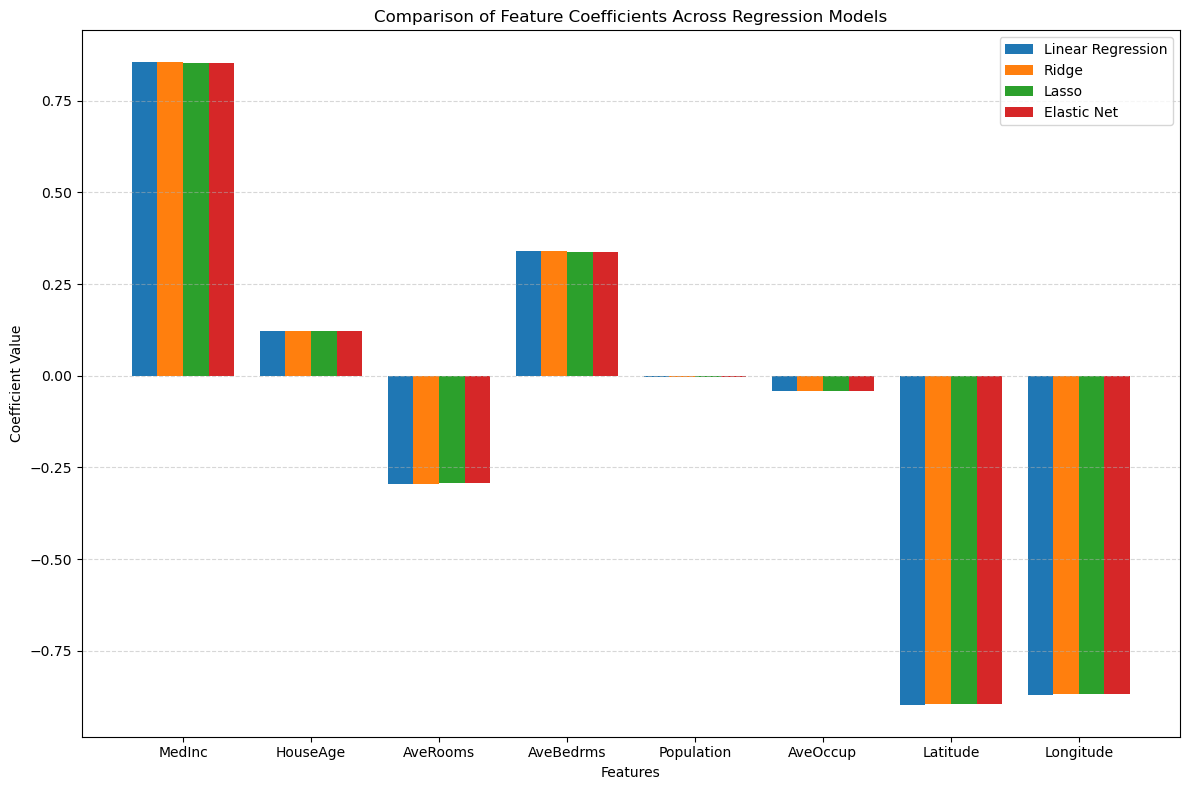

In [52]:

x = np.arange(len(data1['Feature']))
width = 0.2

plt.figure(figsize=(12,8))

# Plot grouped bars
plt.bar(x - 1.5*width, data1['Linear Regression'], width, label='Linear Regression')
plt.bar(x - 0.5*width, data1['Ridge'], width, label='Ridge')
plt.bar(x + 0.5*width, data1['Lasso'], width, label='Lasso')
plt.bar(x + 1.5*width, data1['Elastic Net'], width, label='Elastic Net')

# Labels and formatting
plt.xticks(x, data1['Feature'])
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Feature Coefficients Across Regression Models')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

Coefficient shrinkage

The graph shows that the coefficients estimated by Linear Regression, Ridge, Lasso, and Elastic Net are very similar, with only slight reductions in the regularized models. 
Ridge Regression shrinks the coefficients moderately towards zero while retaining all features, whereas Lasso and Elastic Net apply slightly stronger shrinkage because of the L1 penalty. 
However, none of the coefficients were reduced to exactly zero, which indicates that no features were eliminated from the model. This suggests that all eight features contributed meaningfully to predicting the target variable.

Feature selection

The coefficient comparison indicates that no automatic feature selection occurred in this analysis. Although Lasso Regression and Elastic Net are designed to perform feature selection by shrinking less important coefficients to exactly zero, all features retained non-zero coefficients across the four models. This suggests that every feature contributed some predictive information to the model and none were considered sufficiently unimportant to be excluded.

Predictive performance

The predictive performance results show that all four models performed similarly, with only slight differences in the evaluation metrics. Ridge Regression achieved nearly identical performance to Linear Regression, while Lasso and Elastic Net produced slightly lower values of MSE, MAE, and RMSE, along with a marginally higher R². However, these improvements were extremely small and are unlikely to be of practical significance. This indicates that regularization had little impact on prediction accuracy for this dataset, suggesting that the original Linear Regression model was already well-suited to the data.

The final recommended model.

Lasso Regression is recommended as the final model because it achieved the lowest prediction error (MSE and RMSE) while attaining the highest coefficient of determination (R²), although the improvement over the other models was marginal. Its L1 regularization also provides the added advantage of automatic feature selection when appropriate, resulting in a simpler and more interpretable model. While no coefficients were reduced to zero in this study, Lasso demonstrated the best overall predictive performance and is therefore the preferred model for this dataset.

Question 10

In [53]:
from sklearn.linear_model import SGDRegressor

sgd_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SGDRegressor(max_iter=1000, tol=1e-3, random_state=42))
])
sgd_pipeline.fit(X_train, y_train)
sgd_test_pipeline = sgd_pipeline.predict(X_test)

print("---SGD Regressor Test metrics---")
print(f"MSE:  {mean_squared_error(y_test, sgd_test_pipeline):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, sgd_test_pipeline)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, sgd_test_pipeline):.4f}")

---SGD Regressor Test metrics---
MSE:  0.5506
RMSE: 0.7420
MAE:  0.5299
